# Task 1: Potential problems in linear regression 

### This exercise explores the various issues that can arise when fitting a model to data, why these issues should be adressed, and how to detect and remedy them.

## Issue 1: Non-linearity of the response-predictor relationships

**Exploration:** Assuming a linear relationship between the predictor and response is often the starting point during a model fit assessment. The problem with this, however, is that the relationship between the predictor and response may actually be non-linear. The slope between the predictor and response variable may not be consistent. And this could mean you are incorrectly attempting to fit an inappropriate model to your data, which, in reality, should model the non-linear relationship between the predictor and response. This is an issue because using a model that assumes a linear relationship when in reality it is non-linear can make your predictions systematically inaccurate. You can detect non-linearity in your data by plotting the residual values against the fitted values when using a model that assumes a linear relationship. If you detect a pattern between the two, this may indicate that the model, assuming a linear relationship, did not capture the relationship correctly. You can address this by adding polynomial terms (i.e., predictor ^2) until there is no longer a discernible pattern between the residual and fitted values, indicating the existing errors are most likely only due to random noise and you’ve successfully addressed the non-linearity of the response predictor problem. 



**Question:** One question I had was if the polynomial term is created using the predictor^2 or response^2. I learned that the predictor is the term that receives these degrees because it is independent while the predictor depends on it. Therefore, modifications should be made on the predictor end and not the response. 

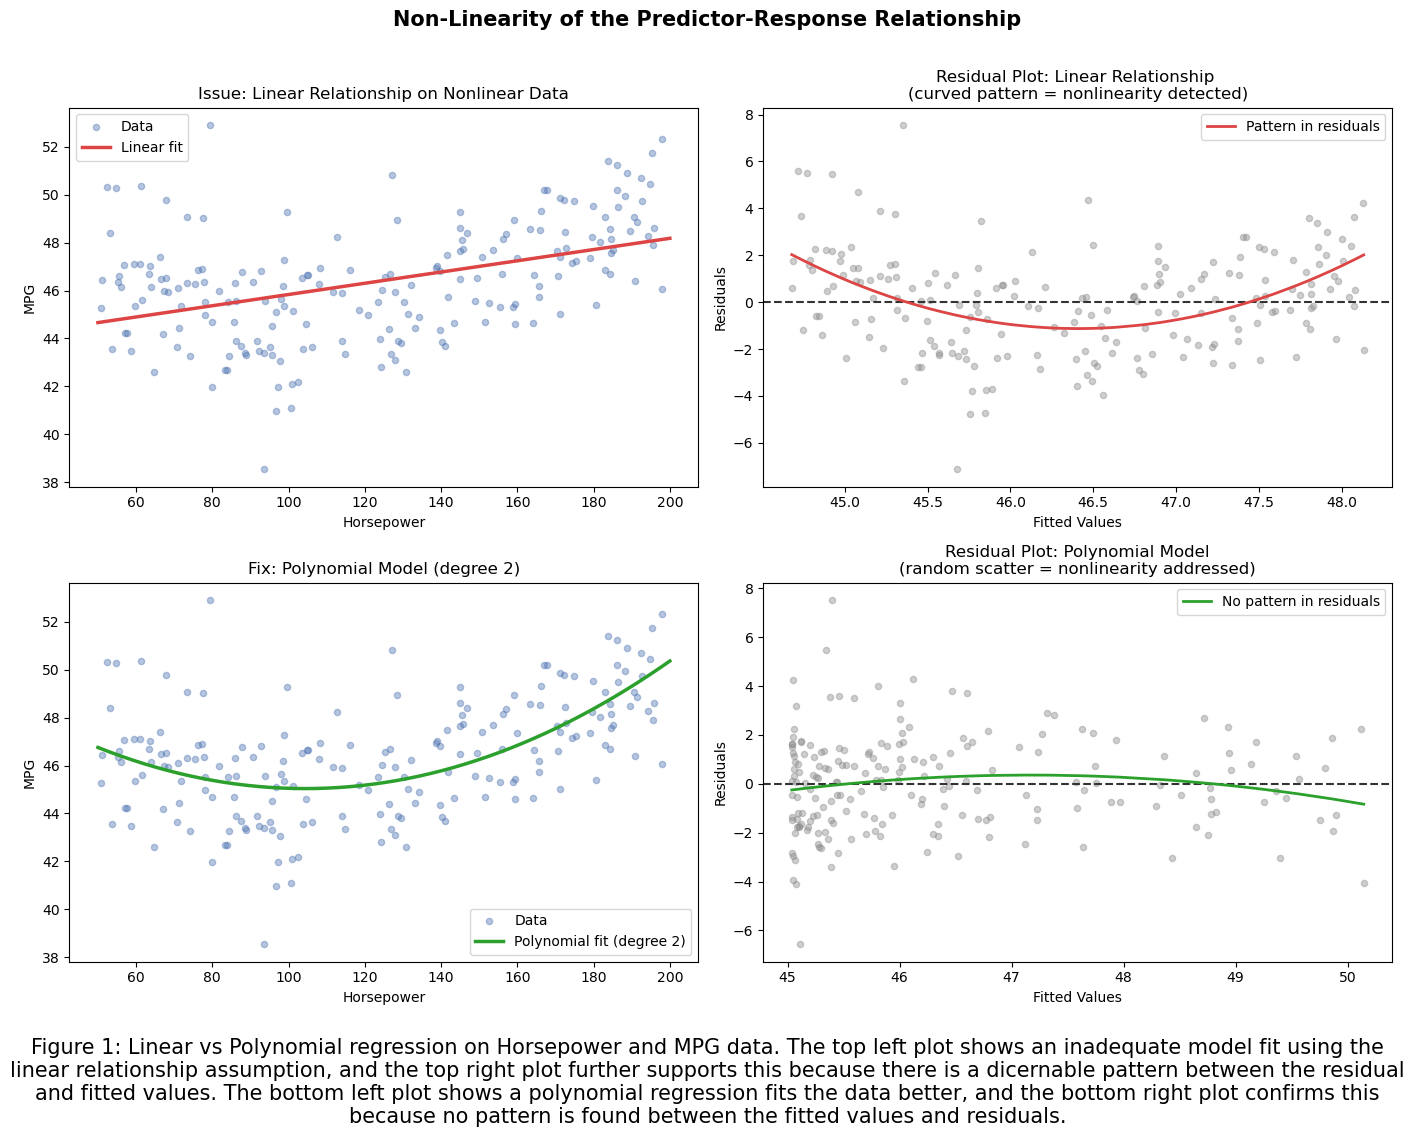

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

np.random.seed(42)

# --- Synthetic Data ---
# True relationship: mpg = 50 - 0.1*horsepower + 0.0005*horsepower^2 + noise
n = 200
horsepower = np.random.uniform(50, 200, n)
noise = np.random.normal(0, 2, n)
mpg = 50 - 0.1 * horsepower + 0.0005 * horsepower**2 + noise  # true nonlinear relationship

X = horsepower.reshape(-1, 1)
hp_range = np.linspace(50, 200, 300).reshape(-1, 1)

# --- Fit Models ---
linear_model = LinearRegression().fit(X, mpg)
poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression()).fit(X, mpg)

linear_preds = linear_model.predict(X)
poly_preds = poly_model.predict(X)

linear_resid = mpg - linear_preds
poly_resid = mpg - poly_preds

# --- Plot ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Non-Linearity of the Predictor-Response Relationship", fontsize=15, fontweight='bold', y=1.01)
fig.text(0.5, -0.1, 
        "Figure 1: Linear vs Polynomial regression on Horsepower and MPG data. The top left plot "
        "shows an inadequate model fit using the linear relationship assumption, and "
        "the top right plot further supports this because there is a dicernable pattern " 
        "between the residual and fitted values. The bottom left plot shows a polynomial " 
        "regression fits the data better, and the bottom right plot confirms this because " 
        "no pattern is found between the fitted values and residuals.",
         ha='center', fontsize=15, color='black', wrap=True)

colors = {
    'scatter': '#4C72B0',
    'linear': '#DD4444',
    'poly': '#2ca02c',
    'resid': '#888888',
    'zero': '#333333'
}

# --- Plot 1: Data + Linear Fit ---
ax1 = axes[0, 0]
ax1.scatter(horsepower, mpg, alpha=0.4, color=colors['scatter'], s=20, label='Data')
ax1.plot(hp_range, linear_model.predict(hp_range), color=colors['linear'], linewidth=2.5, label='Linear fit')
ax1.set_xlabel('Horsepower')
ax1.set_ylabel('MPG')
ax1.set_title('Issue: Linear Relationship on Nonlinear Data')
ax1.legend()

# --- Plot 2: Residuals vs Fitted (Linear) ---
ax2 = axes[0, 1]
ax2.scatter(linear_preds, linear_resid, alpha=0.4, color=colors['resid'], s=20)
ax2.axhline(0, color=colors['zero'], linewidth=1.5, linestyle='--')
# Add a smoothed trend line to make the curve visible
from numpy.polynomial.polynomial import polyfit
coefs = polyfit(linear_preds, linear_resid, 2)
x_sorted = np.sort(linear_preds)
ax2.plot(x_sorted, coefs[0] + coefs[1]*x_sorted + coefs[2]*x_sorted**2,
         color=colors['linear'], linewidth=2, label='Pattern in residuals')
ax2.set_xlabel('Fitted Values')
ax2.set_ylabel('Residuals')
ax2.set_title('Residual Plot: Linear Relationship \n(curved pattern = nonlinearity detected)')
ax2.legend()

# --- Plot 3: Data + Polynomial Fit ---
ax3 = axes[1, 0]
ax3.scatter(horsepower, mpg, alpha=0.4, color=colors['scatter'], s=20, label='Data')
ax3.plot(hp_range, poly_model.predict(hp_range), color=colors['poly'], linewidth=2.5, label='Polynomial fit (degree 2)')
ax3.set_xlabel('Horsepower')
ax3.set_ylabel('MPG')
ax3.set_title('Fix: Polynomial Model (degree 2)')
ax3.legend()

# --- Plot 4: Residuals vs Fitted (Polynomial) ---
ax4 = axes[1, 1]
ax4.scatter(poly_preds, poly_resid, alpha=0.4, color=colors['resid'], s=20)
ax4.axhline(0, color=colors['zero'], linewidth=1.5, linestyle='--')
coefs2 = polyfit(poly_preds, poly_resid, 2)
x_sorted2 = np.sort(poly_preds)
ax4.plot(x_sorted2, coefs2[0] + coefs2[1]*x_sorted2 + coefs2[2]*x_sorted2**2,
         color=colors['poly'], linewidth=2, label='No pattern in residuals')
ax4.set_xlabel('Fitted Values')
ax4.set_ylabel('Residuals')
ax4.set_title('Residual Plot: Polynomial Model\n(random scatter = nonlinearity addressed)')
ax4.legend()

plt.tight_layout()

## Issue 2: Non-constant variance of error terms 

**Exploration:** The problem with having non-constant variance of error terms is that, depending on what the predictor value is, the error can vary. This matters because it can mean the standard error, confidence interval, and p-values you predict are untrustworthy; they don't consistently apply to every prediction. Also, the accuracy of your prediction depends on the predictor value, and it shouldn’t be this way. You can detect this by plotting the fitted values against the residual values and looking for patterns like funneling, which can indicate that smaller prediction values have less error variance while larger prediction values have a larger variance. You can address an issue like funneling by log-transforming the response variable so that even as the predictor increases, the response doesn't get as large as it would if the log weren’t fit to it. This shrinking of the response can help ensure the variance remains consistent both at small values and large values. 

**Question:** One question I had was how using weighted least squares can help solve the issue of non-constant error variance. I learned creating a model where observations with less variance hold more weight on the model prediction while observations with more variance hold less weight can help ensure the model doesn't get dragged off course by observations with high variance. 

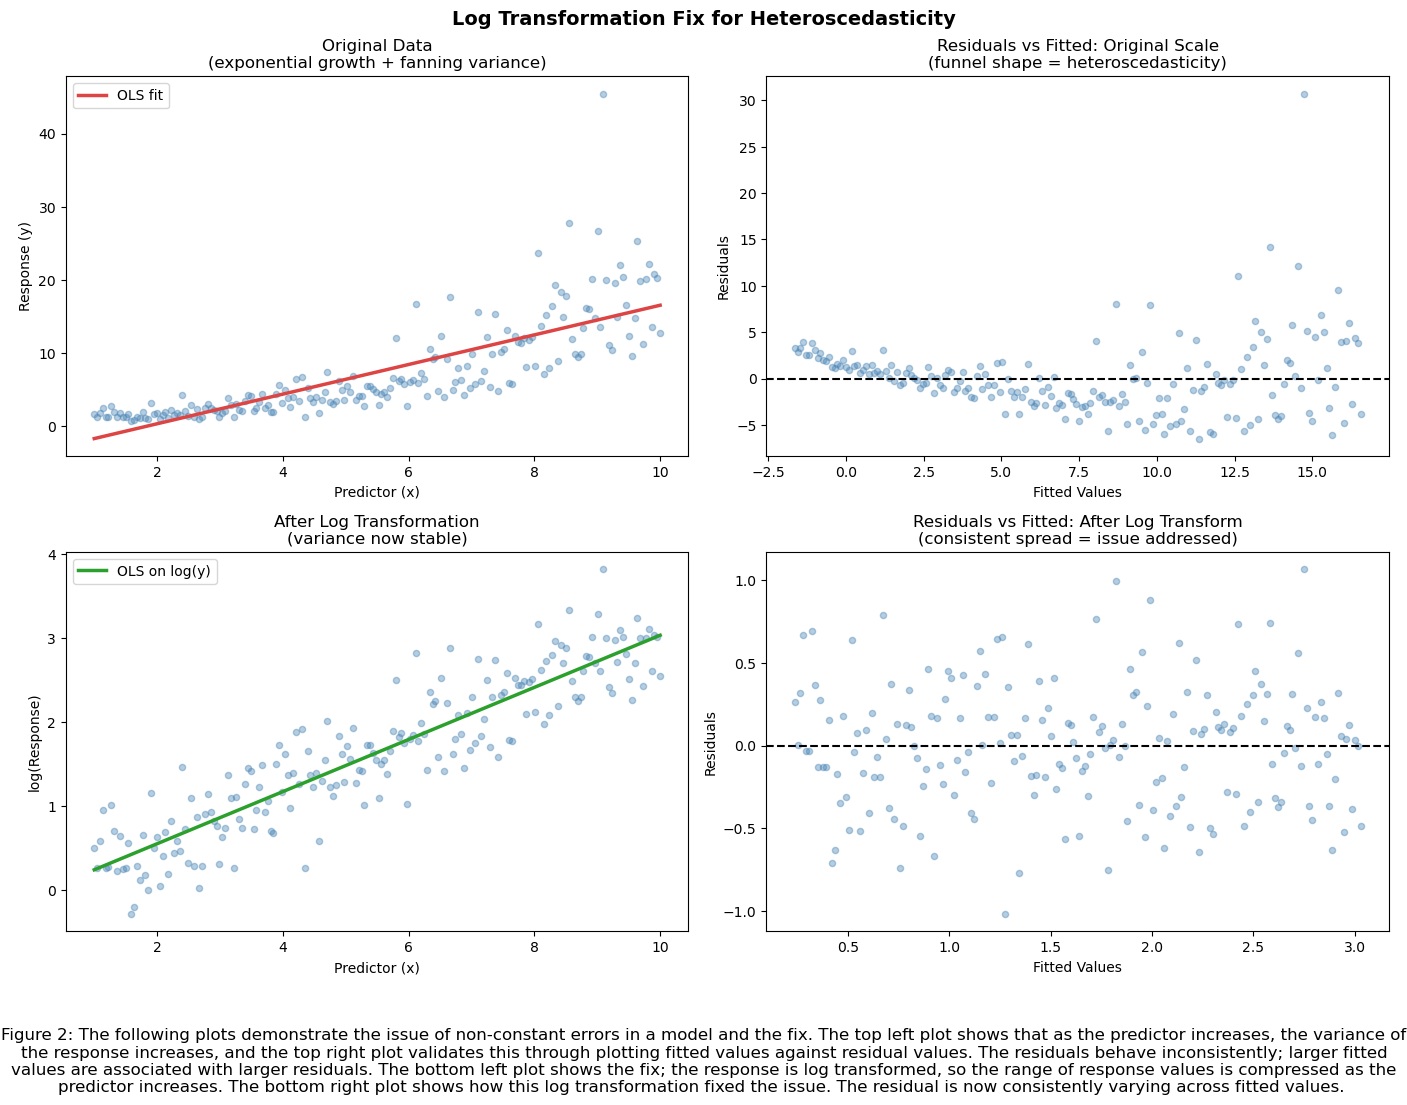

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

np.random.seed(42)

n = 200
x = np.linspace(1, 10, n)
X = x.reshape(-1, 1)

# --- Multiplicative noise: y = exp(1.5x) * noise ---
# This is the natural case where log transformation is appropriate
log_y_true = 0.3 * x  # true relationship on log scale
noise_mult = np.random.normal(0, 0.4, n)  # additive noise on log scale
y = np.exp(log_y_true + noise_mult)  # on original scale this is heteroscedastic

# --- OLS on original scale ---
ols = LinearRegression().fit(X, y)
ols_fitted = ols.predict(X)
ols_resid = y - ols_fitted

# --- OLS on log scale ---
y_log = np.log(y)
ols_log = LinearRegression().fit(X, y_log)
log_fitted = ols_log.predict(X)
log_resid = y_log - log_fitted

# --- Plot ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Log Transformation Fix for Heteroscedasticity", fontsize=14, fontweight='bold')
fig.text(0.5, -0.1, 
        "Figure 2: The following plots demonstrate the issue of non-constant errors in a model and "
        "the fix. The top left plot shows that as the predictor increases, the variance of the "
        "response increases, and the top right plot validates this through plotting fitted values " \
        "against residual values. The residuals behave inconsistently; larger fitted values are " \
        "associated with larger residuals. The bottom left plot shows the fix; the response is log " \
        "transformed, so the range of response values is compressed as the predictor increases. " \
        "The bottom right plot shows how this log transformation fixed the issue. The residual is " \
        "now consistently varying across fitted values. ",
         ha='center', fontsize=12, color='black', wrap=True)

# Top left: original data
ax = axes[0, 0]
ax.scatter(x, y, alpha=0.4, color='steelblue', s=20)
ax.plot(x, ols_fitted, color='#DD4444', linewidth=2.5, label='OLS fit')
ax.set_xlabel('Predictor (x)')
ax.set_ylabel('Response (y)')
ax.set_title('Original Data\n(exponential growth + fanning variance)')
ax.legend()

# Top right: residuals original scale
ax = axes[0, 1]
ax.scatter(ols_fitted, ols_resid, alpha=0.4, color='steelblue', s=20)
ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted: Original Scale\n(funnel shape = heteroscedasticity)')

# Bottom left: log transformed data
ax = axes[1, 0]
ax.scatter(x, y_log, alpha=0.4, color='steelblue', s=20)
ax.plot(x, log_fitted, color='#2ca02c', linewidth=2.5, label='OLS on log(y)')
ax.set_xlabel('Predictor (x)')
ax.set_ylabel('log(Response)')
ax.set_title('After Log Transformation\n(variance now stable)')
ax.legend()

# Bottom right: residuals log scale
ax = axes[1, 1]
ax.scatter(log_fitted, log_resid, alpha=0.4, color='steelblue', s=20)
ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted: After Log Transform\n(consistent spread = issue addressed)')

plt.tight_layout()

## Issue 3: Collinearity 

**Exploration:** The problem with having predictors that have colinearity is that if predictors are related to each other we could have a variety of predictor values that lead to the same response variable. An increase in predictor 1 and a decrease in predictor 2 could potentially produce the same response as a decrease in predictor 1 and an increase in predictor 2. This means the T statistic for a model like this is smaller for both predictors and therefore they receive insignificant p-values regardless of the fact that both could be strong predictors of the response individually. This matters because colinearity could hide the significance of the relationship each individual predictor might have on the response. This can be detected by looking at the correlation matrix of the predictors if there are only two predictors. Large absolute values indicate high colinearity between predictors. With multicollinearity, a better approach is calculating the VIF. This can be addressed by dropping one predictor from the model if it is highly correlated with another, since the other predictor already captures a similar relationship with the response anyway. Alternatively, collinear predictors could be combined into one synthetic predictor representing both of them. 

**Question:** One question I had was how the spread-out contour plot showed that there was no collinearity between the predictors, while the one that was compressed along a specific direction did. What I learned was that the spread out one shows that a unique combination of predictors lead to the smallest RSS becasue as you move away from the center of the circle, the RSS equally gets larger. But the directional contour plot shows that a wide variety of predictor combinations could produce similar RSS values. Many different combinations could lead to the same RSS value. This highlights how closely related they are. 

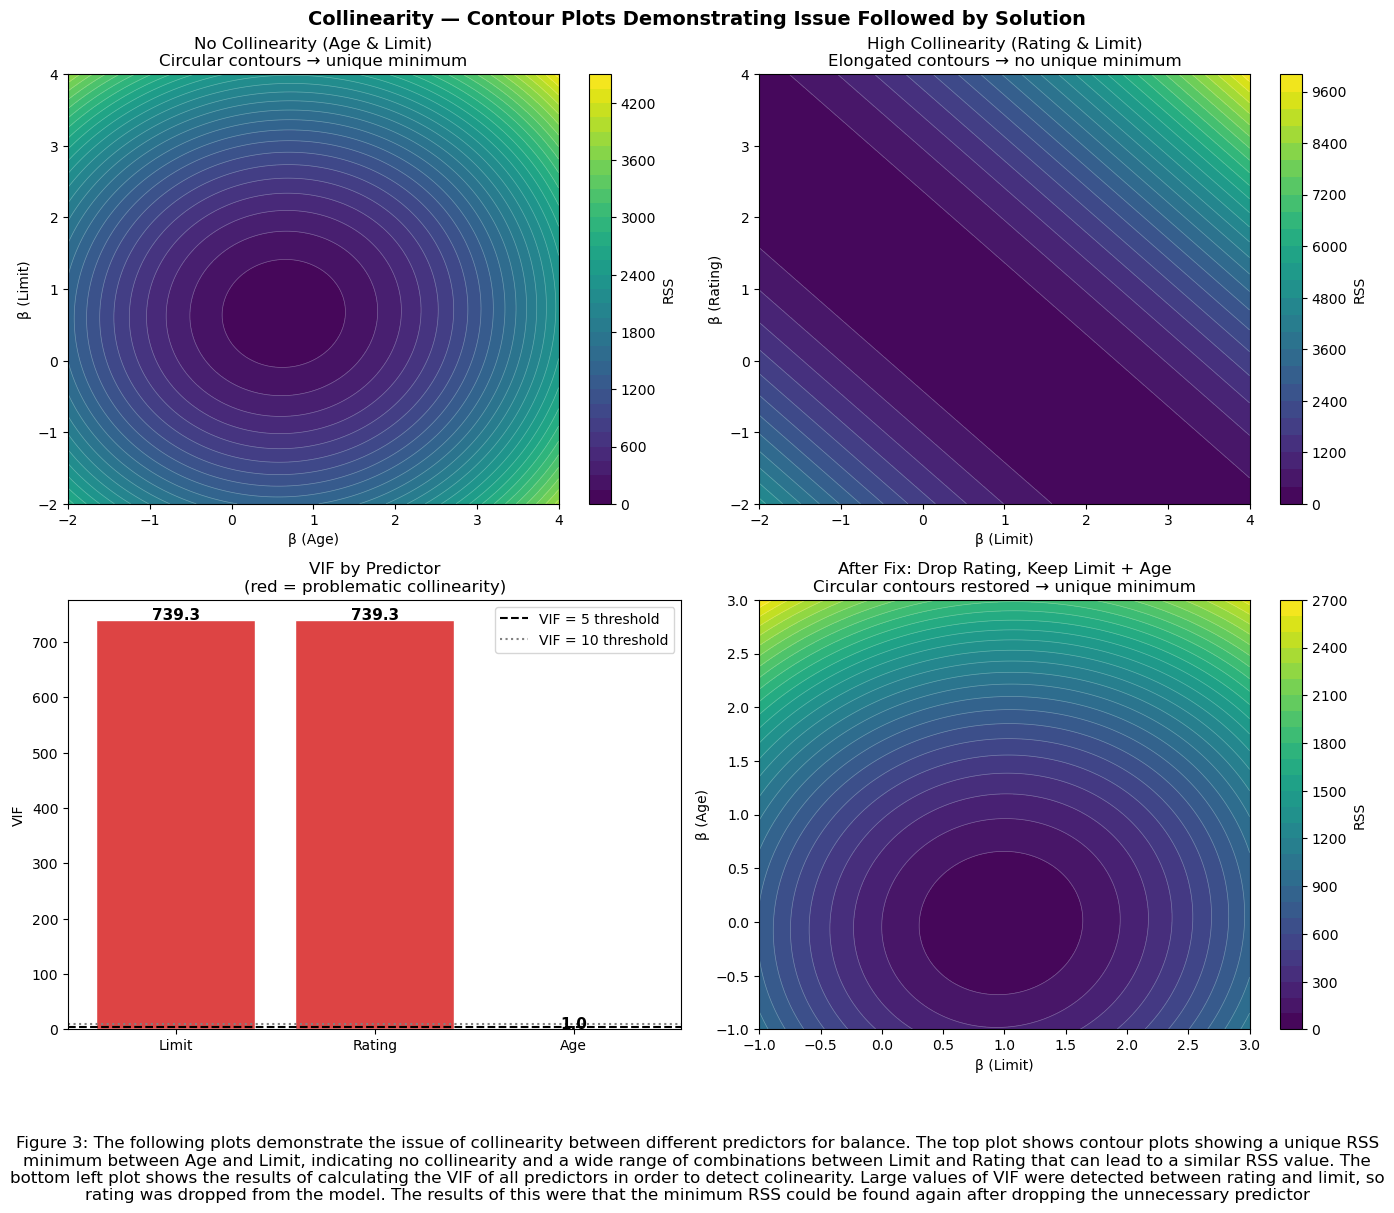

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from numpy.linalg import lstsq

np.random.seed(42)
n = 200

# --- Non-collinear predictors: age and limit ---
age = np.random.uniform(20, 70, n)
limit = np.random.uniform(1000, 10000, n)
balance_nc = 0.5 * age + 0.003 * limit + np.random.normal(0, 5, n)

# --- Collinear predictors: rating and limit ---
limit2 = np.random.uniform(1000, 10000, n)
rating = 0.01 * limit2 + np.random.normal(0, 1, n)
balance_c = 0.5 * rating + 0.003 * limit2 + np.random.normal(0, 5, n)

def scale(v): return (v - v.mean()) / v.std()

def compute_rss(X, y, b1_vals, b2_vals):
    rss = np.zeros((len(b2_vals), len(b1_vals)))
    for i, b2 in enumerate(b2_vals):
        for j, b1 in enumerate(b1_vals):
            preds = b1 * X[:, 0] + b2 * X[:, 1]
            rss[i, j] = np.sum((y - preds) ** 2)
    return rss

def compute_vif(X_df):
    vifs = {}
    for col in X_df.columns:
        y_ = X_df[col].values
        X_ = X_df.drop(columns=[col]).values
        ss_tot = np.sum((y_ - y_.mean()) ** 2)
        res = y_ - X_ @ lstsq(X_, y_, rcond=None)[0]
        r2 = 1 - np.sum(res ** 2) / ss_tot
        vifs[col] = 1 / (1 - r2) if r2 < 1 else np.inf
    return vifs

X_nc = np.column_stack([scale(age), scale(limit)])
X_c  = np.column_stack([scale(limit2), scale(rating)])

b_range = np.linspace(-2, 4, 200)
rss_nc = compute_rss(X_nc, scale(balance_nc), b_range, b_range)
rss_c  = compute_rss(X_c,  scale(balance_c),  b_range, b_range)

# Fix: drop rating
X_fixed = np.column_stack([scale(limit2), scale(age)])
b_range2 = np.linspace(-1, 3, 200)
rss_fixed = compute_rss(X_fixed, scale(balance_c), b_range2, b_range2)

# VIF
df_c = pd.DataFrame({'Limit': scale(limit2), 'Rating': scale(rating), 'Age': scale(age)})
vifs = compute_vif(df_c)

# --- Combined Figure ---
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("Collinearity — Contour Plots Demonstrating Issue Followed by Solution", fontsize=14, fontweight='bold')
fig.text(0.5, -0.1, 
        "Figure 3: The following plots demonstrate the issue of collinearity between different " 
        "predictors for balance. The top plot shows contour plots showing a unique RSS minimum " \
        "between Age and Limit, indicating no collinearity and a wide range of combinations between " \
        "Limit and Rating that can lead to a similar RSS value. The bottom left plot shows the results " \
        "of calculating the VIF of all predictors in order to detect colinearity. Large values of VIF " \
        "were detected between rating and limit, so rating was dropped from the model. The results of " \
        "this were that the minimum RSS could be found again after dropping the unnecessary predictor",
         ha='center', fontsize=12, color='black', wrap=True)


levels = 30

# Top left: circular contours (no collinearity)
cp1 = axes[0, 0].contourf(b_range, b_range, rss_nc, levels=levels, cmap='viridis')
axes[0, 0].contour(b_range, b_range, rss_nc, levels=levels, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(cp1, ax=axes[0, 0], label='RSS')
axes[0, 0].set_xlabel('β (Age)')
axes[0, 0].set_ylabel('β (Limit)')
axes[0, 0].set_title('No Collinearity (Age & Limit)\nCircular contours → unique minimum')

# Top right: elongated contours (collinearity)
cp2 = axes[0, 1].contourf(b_range, b_range, rss_c, levels=levels, cmap='viridis')
axes[0, 1].contour(b_range, b_range, rss_c, levels=levels, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(cp2, ax=axes[0, 1], label='RSS')
axes[0, 1].set_xlabel('β (Limit)')
axes[0, 1].set_ylabel('β (Rating)')
axes[0, 1].set_title('High Collinearity (Rating & Limit)\nElongated contours → no unique minimum')

# Bottom left: VIF bar chart
ax = axes[1, 0]
colors_vif = ['#DD4444' if v > 5 else '#2ca02c' for v in vifs.values()]
bars = ax.bar(vifs.keys(), vifs.values(), color=colors_vif, edgecolor='white')
ax.axhline(5, color='black', linestyle='--', linewidth=1.5, label='VIF = 5 threshold')
ax.axhline(10, color='gray', linestyle=':', linewidth=1.5, label='VIF = 10 threshold')
for bar, val in zip(bars, vifs.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('VIF')
ax.set_title('VIF by Predictor\n(red = problematic collinearity)')
ax.legend()

# Bottom right: fixed contour after dropping rating
cp3 = axes[1, 1].contourf(b_range2, b_range2, rss_fixed, levels=30, cmap='viridis')
axes[1, 1].contour(b_range2, b_range2, rss_fixed, levels=30, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(cp3, ax=axes[1, 1], label='RSS')
axes[1, 1].set_xlabel('β (Limit)')
axes[1, 1].set_ylabel('β (Age)')
axes[1, 1].set_title('After Fix: Drop Rating, Keep Limit + Age\nCircular contours restored → unique minimum')

plt.tight_layout()

## Generative AI reflection:

I used Claude for the generative AI task. I essentially explained each issue I decided to explore and then gave it a real-world example for each that I came across in the book. Then, I told it to generate synthetic code that shows the issue, a plot for the issue, and additional plots showing how to solve the issue and the result of that. It took me about 3 tries for the collinearity problem and 1 or 2 tries for the rest. One mistake it made was that it didn't show that, after log-transforming the response variable, there was no longer a pattern between the fitted and residual values. Initially, the pattern was still there, so I let it know that, and it gave me different synthetic data showing the fix more clearly. 